## E-COMMERS PROJECT

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
import streamlit as st

In [2]:
df = pd.read_csv("E:/Python/Project/E Commerce/E_Commers_Data.csv" ,encoding = 'latin-1')

In [3]:
df.head()

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
0,943146,5876328741,Female,25-45,30/08/2023 20:27:08,Electronics,Yes,FESTIVE50,64.30,725.304000,661.004000,Credit Card,Ahmedabad
1,180079,1018503182,Male,25-45,23/02/2024 09:33:46,Electronics,Yes,SEASONALOFFER21,175.19,4638.991875,4463.801875,Credit Card,Bangalore
2,337580,3814082218,Other,60 and above,06/03/2022 09:09:50,Clothing,Yes,SEASONALOFFER21,211.54,1986.372575,1774.832575,Credit Card,Delhi
3,180333,1395204173,Other,60 and above,04/11/2020 04:41:57,Sports & Fitness,No,NaN,0.00,5695.612650,5695.612650,Debit Card,Delhi
4,447553,8009390577,Male,18-25,31/05/2022 17:00:32,Sports & Fitness,Yes,WELCOME5,439.92,2292.651500,1852.731500,Credit Card,Delhi


In [4]:
df.tail()

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
54995,295864,5407639888,Other,25-45,23/02/2020 10:42:04,Electronics,Yes,SEASONALOFFER21,110.89,2819.9073,2709.0173,Debit Card,Other
54996,706435,1144029904,Other,18-25,12/07/2021 15:59:21,Electronics,Yes,SEASONALOFFER21,488.59,3891.3039,3402.7139,Cash on Delivery,Bangalore
54997,649435,9587323189,Male,45-60,02/08/2024 09:30:44,Home & Kitchen,Yes,NEWYEARS,417.63,4094.6875,3677.0575,Credit Card,Mumbai
54998,982183,5032564481,Female,45-60,05/08/2020 23:57:56,Beauty and Health,Yes,SEASONALOFFER21,204.56,3977.4735,3772.9135,Credit Card,Kolkata
54999,126691,9172953722,Male,25-45,21/07/2022 09:05:18,Beauty and Health,Yes,NEWYEARS,380.81,3703.5819,3322.7719,Credit Card,Mumbai


In [5]:
df.describe()

,CID,TID,Discount Amount (INR),Gross Amount,Net Amount
count,55000.000000,5.500000e+04,55000.000000,55000.000000,55000.000000
mean,551245.593891,5.504740e+09,136.986796,3012.936606,2875.949810
std,260603.330337,2.594534e+09,165.375502,1718.431066,1726.127778
min,100009.000000,1.000163e+09,0.000000,136.454325,-351.119775
25%,323717.000000,3.252604e+09,0.000000,1562.111325,1429.551863
50%,550088.500000,5.498383e+09,0.000000,2954.266150,2814.910875
75%,776955.750000,7.747933e+09,274.115000,4342.221675,4211.407838
max,999996.000000,9.999393e+09,500.000000,8394.825600,8394.825600


### Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CID                    55000 non-null  int64  
 1   TID                    55000 non-null  int64  
 2   Gender                 55000 non-null  object 
 3   Age Group              55000 non-null  object 
 4   Purchase Date          55000 non-null  object 
 5   Product Category       55000 non-null  object 
 6   Discount Availed       55000 non-null  object 
 7   Discount Name          27415 non-null  object 
 8   Discount Amount (INR)  55000 non-null  float64
 9   Gross Amount           55000 non-null  float64
 10  Net Amount             55000 non-null  float64
 11  Purchase Method        55000 non-null  object 
 12  Location               55000 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 5.5+ MB


### KPI'S Metrics

In [7]:
print(f"Total Customers: {df['CID'].nunique()/1000:.0f}K")
print(f"No of Transactions: {df['TID'].nunique()/1000:.0f}K")
print(f"Total Sales: {df['Net Amount'].sum()/1000000:.2f}M")
print(f"Avg Sales: {df['Net Amount'].mean()/1000:.2f}K")
print(f"Total Discount:{df['Discount Amount (INR)'].mean():.2f}K")

Total Customers: 29K
No of Transactions: 55K
Total Sales: 158.18M
Avg Sales: 2.88K
Total Discount:136.99K


### Total sales by Age Group

      Age Group  Gross Amount
0         18-25  4.904129e+07
1         25-45  6.693434e+07
2         45-60  3.322760e+07
3  60 and above  8.121816e+06
4      under 18  8.386460e+06


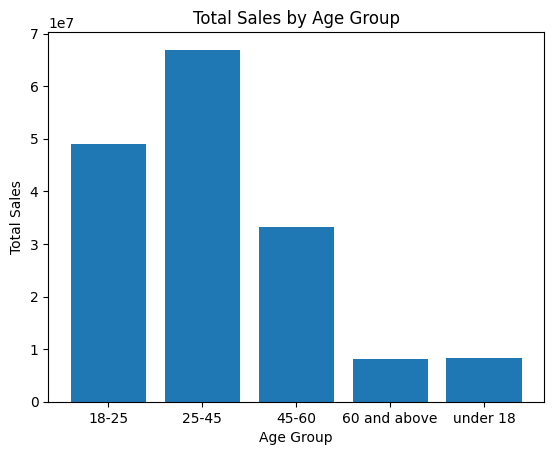

In [8]:
sales_by_age = df.groupby('Age Group')['Gross Amount'].sum().reset_index()           # Total sales by age group

print(sales_by_age)                # Print table

# Create bar chart
plt.figure()
plt.bar(sales_by_age['Age Group'], sales_by_age['Gross Amount'])

# Labels
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.title("Total Sales by Age Group")

plt.show()

### Total sales by Discount

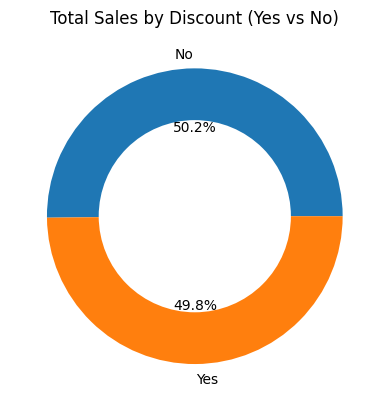

In [9]:
# Total sales by Discount (Yes / No)
sales_by_discount = df.groupby('Discount Availed')['Gross Amount'].sum()

# Create donut chart
plt.figure()
plt.pie(sales_by_discount, labels=sales_by_discount.index, autopct='%1.1f%%')


centre_circle = plt.Circle((0,0),0.65,fc='white')        # Create donut hole
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Total Sales by Discount (Yes vs No)")

plt.show()

### Total sales by Discount Name

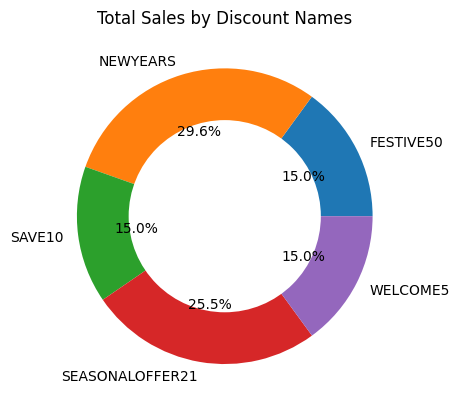

In [10]:
sales_by_discount = df.groupby('Discount Name')['Gross Amount'].sum()

# Create donut chart
plt.figure()
plt.pie(sales_by_discount, labels=sales_by_discount.index, autopct='%1.1f%%')


centre_circle = plt.Circle((0,0),0.65,fc='white')        # Create donut hole
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Total Sales by Discount Names")

plt.show()

### Total sales by Gender

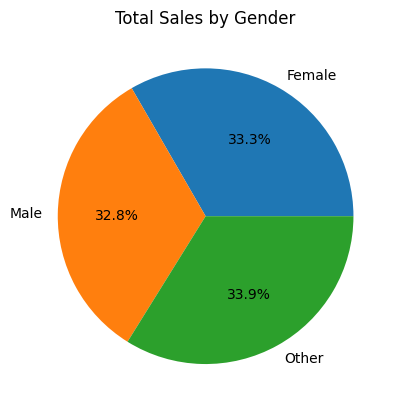

In [11]:
# Total sales by gender
sales_by_gender = df.groupby('Gender')['Gross Amount'].sum()

# Create pie chart
plt.figure()
plt.pie(sales_by_gender, labels=sales_by_gender.index, autopct='%1.1f%%')

# Title
plt.title("Total Sales by Gender")

plt.show()

### Total sales by Loaction

C:\Users\admin\AppData\Local\Temp\ipykernel_1212\50168469.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.scatter_geo(


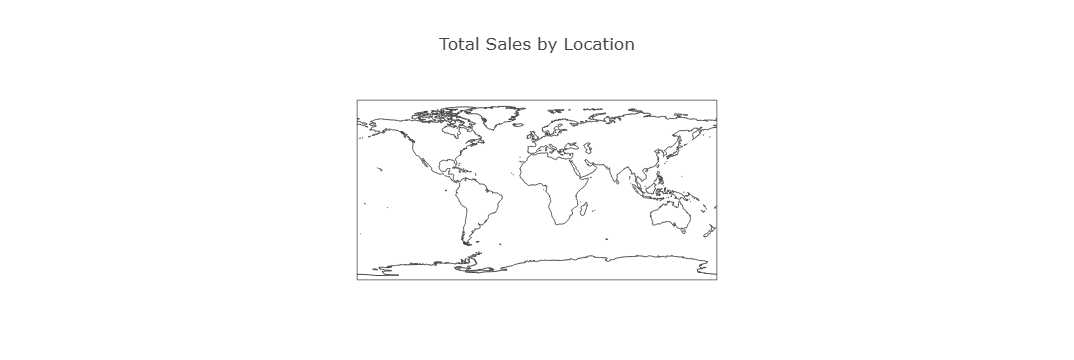

In [12]:
# Total sales by location
sales_by_location = df.groupby('Location')['Gross Amount'].sum().reset_index()

# Create map chart
fig = px.scatter_geo(
    sales_by_location,
    locations="Location",
    locationmode="country names",
    size="Gross Amount",
    title="Total Sales by Location"
)

fig.show()

### Total sales by Product Category

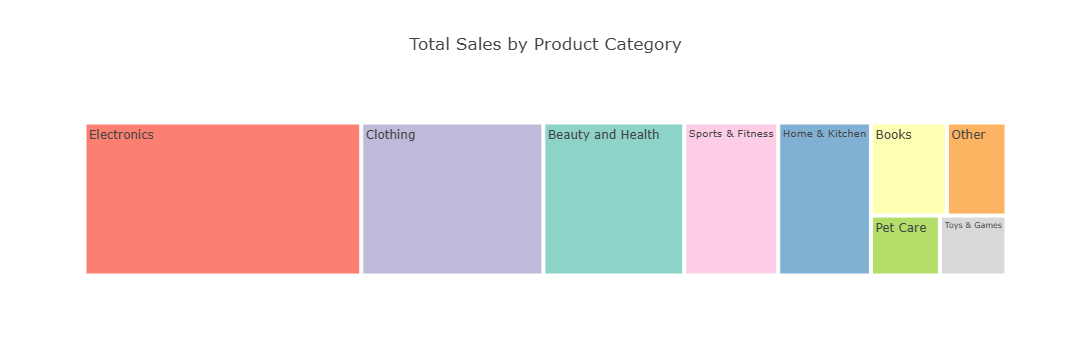

In [15]:
sales_by_category = df.groupby('Product Category')['Gross Amount'].sum().reset_index()   # Total Sales by Product Category

fig = px.treemap(
    sales_by_category,
    path=['Product Category'],
    values='Gross Amount',
    color='Product Category',
    color_discrete_sequence=px.colors.qualitative.Set3,
    title="Total Sales by Product Category"
)
fig.show()